# EDA — E-ComShield

Análise exploratória inicial dos datasets escolhidos para o Projeto de Bloco (TP1).

**Datasets utilizados:**
1. **Bitext Retail eCommerce LLM Chatbot Training Dataset** — sintético, fonte: Hugging Face (bitext/Bitext-retail-ecommerce-llm-chatbot-training-dataset), licença CDLA-Sharing-1.0.
2. **Customer_support_data.csv ("Shopzilla")** — real, com PII ofuscada via Faker, fonte: Kaggle (ddosad/ecommerce-customer-service-satisfaction), licença "Other (specified in description)".

Detalhes completos de fonte, licença e justificativa de escolha estão em `docs/escolha_dataset.md`.


## Uso de IA

Conforme a política "Sinal Verde" do enunciado do TP1, registro aqui o uso de ferramentas de IA
neste trabalho: a estrutura desta análise (sequência de EDA, definição das visualizações e das
hipóteses da Tarefa 3), o script de limpeza (`02_limpeza.py`) e a redação dos textos explicativos
deste notebook foram desenvolvidos com apoio do Claude (Anthropic). A pesquisa e comparação dos
datasets candidatos também contou com apoio da IA, incluindo verificação de licença e estrutura de
colunas. Os resultados numéricos, os gráficos e a validação de cada hipótese foram gerados pela
execução real do código abaixo e conferidos manualmente antes de serem incorporados às conclusões.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_bitext = pd.read_csv('data/bitext-retail-ecommerce-llm-chatbot-training-dataset.csv')
df_shopzilla = pd.read_csv('data/Customer_support_data.csv')

## 1. Primeira olhada nos dados

In [3]:
df_bitext.head()

,instruction,intent,category,tags,response
0,I got to add an item to the cart,add_product,CART,BL,I'll get right on it! I'm here to assist you i...
1,wanna add fucking products to the basket can h...,add_product,CART,BCIMQWZ,I sincerely apologize if you've encountered an...
2,i have to add products to the basket i ned help,add_product,CART,BCMQZ,You bet! I'm here to assist you in adding prod...
3,di like to add products to the cart could i ge...,add_product,CART,BCILMPQZ,Indeed! I'm here to assist you in adding produ...
4,"I need to add an item to the cart , where do I...",add_product,CART,BCILZ,I'll take care of it! I'm here to help you wit...


In [4]:
df_shopzilla.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


## 2. Shape, dtypes, describe, valores ausentes e duplicatas

In [5]:
print("Bitext:", df_bitext.shape)
print("Shopzilla:", df_shopzilla.shape)

Bitext: (44884, 5)
Shopzilla: (85907, 20)


In [6]:
df_bitext.dtypes

instruction    str
intent         str
category       str
tags           str
response       str
dtype: object

In [7]:
df_shopzilla.dtypes

Unique id                      str
channel_name                   str
category                       str
Sub-category                   str
Customer Remarks               str
Order_id                       str
order_date_time                str
Issue_reported at              str
issue_responded                str
Survey_response_Date           str
Customer_City                  str
Product_category               str
Item_price                 float64
connected_handling_time    float64
Agent_name                     str
Supervisor                     str
Manager                        str
Tenure Bucket                  str
Agent Shift                    str
CSAT Score                   int64
dtype: object

In [8]:
df_shopzilla.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


In [9]:
df_bitext.isna().sum()

instruction    0
intent         0
category       0
tags           0
response       0
dtype: int64

O Bitext não tem nenhum valor ausente em nenhuma coluna — é um dataset sintético e bem controlado, então não precisou de nenhuma decisão de limpeza.

In [10]:
df_shopzilla.isna().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

**Decisões de limpeza aplicadas ao Shopzilla** (ver também `agent/02_limpeza.py`, que automatiza essas decisões e gera as versões tratadas em `data/processed/`):

- `Customer Remarks` está vazio em 66,5% das linhas (57.165 de 85.907). Decisão: manter o dataset completo para análises que não dependem de texto, e usar um subconjunto filtrado (`dropna`) para qualquer tarefa que dependa do texto do cliente.
- `connected_handling_time` está preenchido em apenas 0,3% das linhas (242 de 85.907) — inutilizável, decisão: descartar essa coluna.
- `Order_id`, `order_date_time`, `Customer_City`, `Product_category`, `Item_price` têm entre 21% e 80% de ausência — decisão: usar apenas nas análises específicas onde há dado suficiente, sem preenchimento artificial.
- Colunas de data (`order_date_time`, `Issue_reported at`, `issue_responded`, `Survey_response_Date`) estão sendo lidas como texto — decisão: converter para datetime quando alguma análise precisar calcular tempo de resposta.
- `Agent_name`, `Supervisor`, `Manager`, `Customer_City` foram gerados artificialmente via biblioteca Faker (conforme a descrição do próprio dataset, que ofusca identificação real por privacidade) — decisão: tratar como não analíticos, não usar em nenhuma inferência real.

In [11]:
print("Duplicatas Bitext:", df_bitext.duplicated().sum())
print("Duplicatas Shopzilla:", df_shopzilla.duplicated().sum())

Duplicatas Bitext: 0


Duplicatas Shopzilla: 0


Nenhum dos dois datasets tem linhas duplicadas.

## 3. Distribuição das categorias/intenções

In [12]:
df_bitext['category'].value_counts()

category
RETURNS        6925
PRODUCT        6679
DELIVERY       6595
ACCOUNT        4950
ORDER          3945
PAYMENT        2981
FEEDBACK       2980
APP_WEBSITE    1993
CONTACT        1986
CART           1950
STORE          1916
SALES           995
USER            989
Name: count, dtype: int64

In [13]:
df_bitext['intent'].value_counts()

intent
request_invoice                   1000
refund_status                      999
use_app                            999
cancel_order                       996
delivery_issue                     996
payment_issue                      996
track_delivery                     996
wrong_item                         996
close_account                      995
payment_methods                    995
sales_period                       995
submit_product_idea                995
human_agent                        994
refund_policy                      994
return_policy                      994
return_product                     994
return_product_in_store            994
submit_product_feedback            994
technical_issue                    994
availability_online                993
recover_password                   993
remove_product                     993
return_product_online              993
customer_service                   992
damaged_delivery                   992
product_issue     

In [14]:
df_shopzilla['category'].value_counts()

category
Returns               44097
Order Related         23215
Refund Related         4550
Product Queries        3692
Shopzilla Related      2792
Payments related       2327
Feedback               2294
Cancellation           2212
Offers & Cashback       480
Others                   99
App/website              84
Onboarding related       65
Name: count, dtype: int64

In [15]:
df_shopzilla['Sub-category'].value_counts()

Sub-category
Reverse Pickup Enquiry              22389
Return request                       8523
Delayed                              7388
Order status enquiry                 6922
Installation/demo                    4116
Fraudulent User                      4108
Product Specific Information         3589
Refund Enquiry                       2665
Wrong                                2597
Missing                              2556
UnProfessional Behaviour             2294
General Enquiry                      1945
Not Needed                           1920
Service Centres Related              1875
Refund Related Issues                1800
Invoice request                      1465
Online Payment Issues                1079
Seller Cancelled Order               1059
Priority delivery                     972
Exchange / Replacement                896
Customer Requested Modifications      805
Payment related Queries               743
Signup Issues                         489
Damaged              

**Observação:** a categoria `Others` do Shopzilla tem apenas 99 registros (0,1% do dataset) — qualquer estatística sobre ela precisa ser tratada com ressalva de amostra pequena.

## 4. Visualizações e hipóteses

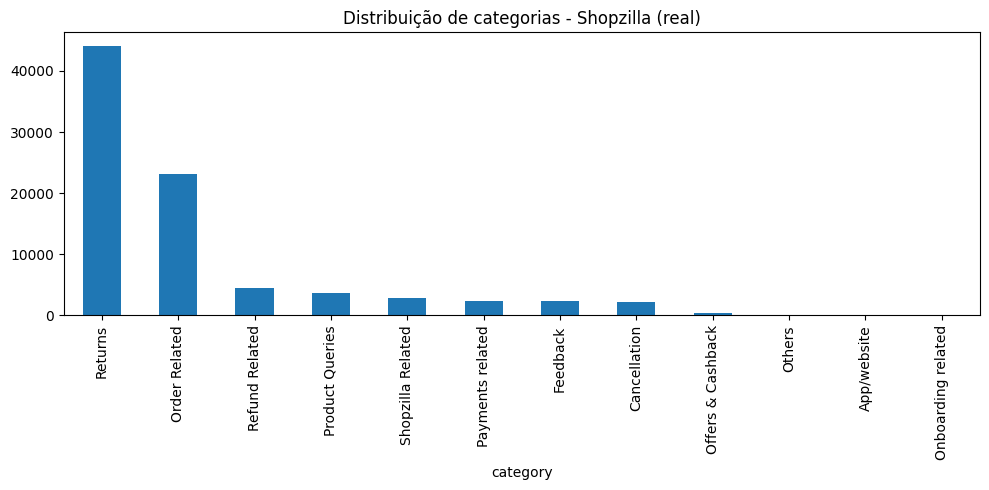

In [16]:
df_shopzilla['category'].value_counts().plot(kind='bar', figsize=(10,5), title='Distribuição de categorias - Shopzilla (real)')
plt.tight_layout()
plt.show()

Olhando essa distribuição, dá pra ver que Returns domina completamente o volume de chamados, sozinha representando mais da metade dos tickets, seguida de Order Related. As demais categorias juntas não chegam nem perto disso. Vou comparar isso com o dataset sintético mais à frente pra entender se esse padrão é uma característica do domínio ou só do jeito que esse dataset específico foi coletado.

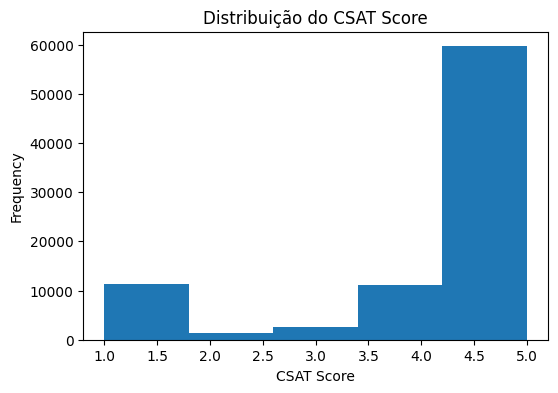

In [17]:
df_shopzilla['CSAT Score'].plot(kind='hist', bins=5, figsize=(6,4), title='Distribuição do CSAT Score')
plt.xlabel('CSAT Score')
plt.show()

A distribuição de CSAT não é uma curva suave, ela tem dois picos bem separados: um grande perto da nota 5 e outro menor perto da nota 1, com pouca coisa no meio. Isso indica que o cliente tende a avaliar de forma polarizada, ou muito satisfeito ou muito insatisfeito, sem muito meio-termo. Vou explorar isso comparando o CSAT médio entre as categorias pra ver se algum tipo de chamado puxa mais pra um lado ou pro outro.

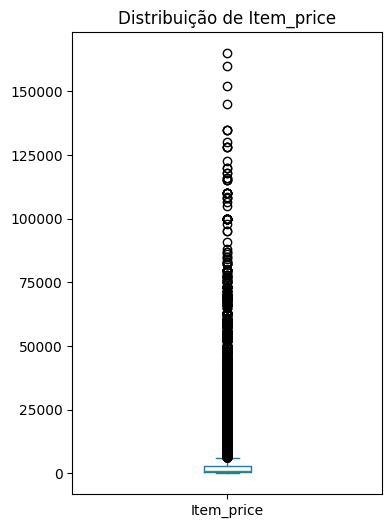

In [18]:
df_shopzilla['Item_price'].plot(kind='box', figsize=(4,6), title='Distribuição de Item_price')
plt.show()

O boxplot mostra que a maioria dos pedidos tem valor baixo, concentrado bem próximo de zero, mas existe uma quantidade grande de outliers chegando a valores bem altos, passando de 150 mil. Isso sugere que vale a pena investigar se esses pedidos mais caros têm um padrão de atendimento diferente dos pedidos comuns.

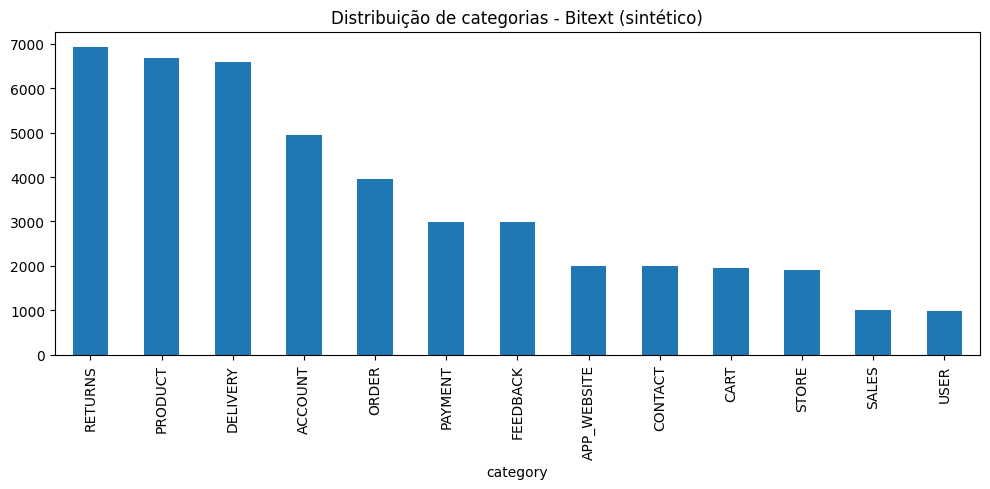

In [19]:
df_bitext['category'].value_counts().plot(kind='bar', figsize=(10,5), title='Distribuição de categorias - Bitext (sintético)')
plt.tight_layout()
plt.show()

**Hipótese 1 — Devolução puxa o volume real de contato.** Comparando esse gráfico com o do Shopzilla, a diferença fica bem clara. No Bitext as categorias ficam relativamente próximas em volume, sem nenhuma dominando de forma exagerada. Já no dado real, Returns sozinha passa de 50% do total. Isso reforça uma limitação natural de datasets sintéticos e balanceados: eles não capturam a concentração real de intenções que aparece quando o dado vem de uma operação de verdade, onde resolver problema pós-compra é disparado o motivo mais comum de contato.

In [20]:
df_shopzilla.groupby('category')['CSAT Score'].mean().sort_values()

category
Others                3.434343
Cancellation          3.990506
Product Queries       4.039816
Order Related         4.096059
Feedback              4.158675
Offers & Cashback     4.210417
Refund Related        4.226813
Onboarding related    4.261538
Shopzilla Related     4.306948
Returns               4.346350
Payments related      4.354534
App/website           4.404762
Name: CSAT Score, dtype: float64

**Hipótese 2 — Satisfação não segue a lógica óbvia de "categoria com atrito = nota baixa".** Eu esperava que categorias ligadas a atrito, como Returns e Refund Related, tivessem CSAT mais baixo, já que envolvem o cliente lidando com algum problema. Porém, Returns teve uma das médias mais altas, 4,35, enquanto quem ficou pior avaliado foi Cancellation e Others. Isso me faz pensar que o processo de devolução do Shopzilla é percebido pelo cliente como bem resolvido, e que o que realmente incomoda é ficar num fluxo sem solução clara, como acontece em cancelamento ou em chamados que nem se encaixam direito numa categoria definida. Vale notar que Others tem só 99 registros, então essa média específica precisa ser vista com cautela por causa do tamanho pequeno da amostra.

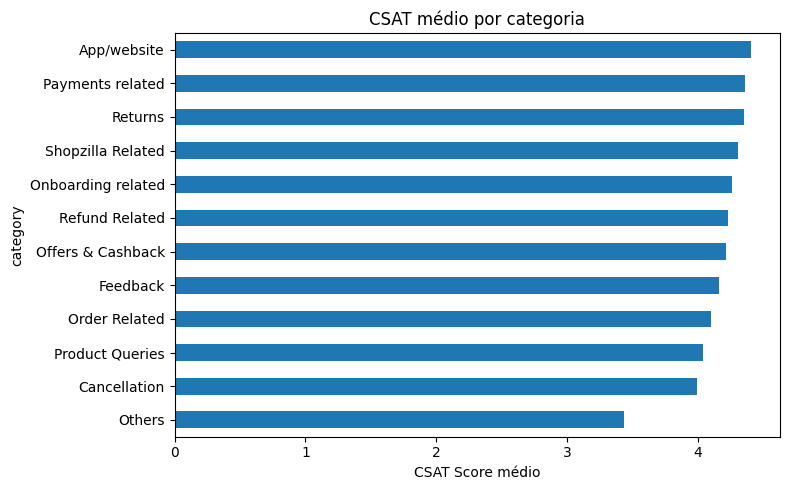

In [21]:
df_shopzilla.groupby('category')['CSAT Score'].mean().sort_values().plot(kind='barh', figsize=(8,5), title='CSAT médio por categoria')
plt.xlabel('CSAT Score médio')
plt.tight_layout()
plt.show()

In [22]:
df_shopzilla['category'].value_counts()['Others']

np.int64(99)

In [23]:
df_shopzilla.groupby('category')['Item_price'].mean().sort_values(ascending=False)

category
Offers & Cashback     15289.237288
Shopzilla Related     13655.750000
Payments related      10459.938776
Product Queries        9187.764706
Cancellation           8195.593516
Order Related          7824.723425
Refund Related         6342.692637
Feedback               4059.988848
Returns                3655.011890
Others                 3511.407407
App/website                    NaN
Onboarding related             NaN
Name: Item_price, dtype: float64

In [24]:
limite = df_shopzilla['Item_price'].quantile(0.95)  # top 5% mais caros
caros = df_shopzilla[df_shopzilla['Item_price'] >= limite]
print("Preço a partir do qual entra no top 5%:", limite)
caros['Sub-category'].value_counts().head(10)

Preço a partir do qual entra no top 5%: 31999.0


Sub-category
Delayed                    230
Order status enquiry       157
Exchange / Replacement      69
Reverse Pickup Enquiry      62
Not Needed                  57
Refund Related Issues       40
Installation/demo           39
Service Centres Related     36
Refund Enquiry              27
Technician Visit            25
Name: count, dtype: int64

In [25]:
prop_geral = df_shopzilla['Sub-category'].value_counts(normalize=True)
prop_caros = caros['Sub-category'].value_counts(normalize=True)

comparacao = pd.DataFrame({'proporcao_geral': prop_geral, 'proporcao_top5_caros': prop_caros}).dropna()
comparacao['diferenca'] = comparacao['proporcao_top5_caros'] - comparacao['proporcao_geral']
comparacao.sort_values('diferenca', ascending=False).head(10)

,proporcao_geral,proporcao_top5_caros,diferenca
Sub-category,,,
Delayed,0.086000,0.264977,0.178977
Order status enquiry,0.080576,0.180876,0.100300
Exchange / Replacement,0.010430,0.079493,0.069063
Not Needed,0.022350,0.065668,0.043318
Refund Related Issues,0.020953,0.046083,0.025130
Technician Visit,0.004400,0.028802,0.024402
Service Centres Related,0.021826,0.041475,0.019649
Priority delivery,0.011315,0.018433,0.007119
Invoice request,0.017053,0.023041,0.005988


**Hipótese 3 — Pedidos de maior valor concentram reclamação de atraso, não de fraude.** Minha primeira suposição era que pedidos de maior valor estariam ligados a atendimento prioritário ou suspeita de fraude. Mas na verdade, a subcategoria Delayed salta de 8,6% no geral pra 26,5% entre os pedidos mais caros, e Order status enquiry mais que dobra, indo de 8,1% pra 18,1%. Já Priority delivery quase não muda. Isso indica que o valor do pedido está muito mais associado à ansiedade do cliente com prazo de entrega e rastreamento do que a qualquer tratamento diferenciado. Parece que quanto mais caro o item, mais o cliente quer saber onde ele está.

## Resumo da análise

Nessa primeira etapa eu trabalhei com dois datasets complementares: o Bitext, sintético e balanceado, com 44.884 exemplos rotulados por intenção, e o Shopzilla, um dataset real de atendimento de e-commerce com 85.907 registros, com identificação de agentes ofuscada por privacidade mas com o conteúdo das interações preservado.

A comparação entre os dois deixou claro que dado sintético e dado real contam histórias diferentes. No Bitext, as categorias ficam relativamente equilibradas entre si. No Shopzilla, Returns sozinha responde por mais da metade dos chamados, o que mostra que resolver problema pós-compra é, de longe, o principal motivo de contato num cenário real de e-commerce.

Sobre satisfação, a intuição inicial de que categorias com atrito teriam pior avaliação não se confirmou: Returns teve CSAT médio alto, enquanto Cancellation e Others tiveram os piores resultados, sugerindo que o processo de devolução em si funciona bem, mas que a falta de um caminho de resolução claro é o que mais frustra o cliente.

Por fim, ao investigar os pedidos de maior valor, encontrei uma concentração bem mais forte de reclamações de atraso e consultas de status do que eu esperava, e quase nenhuma relação com tratamento prioritário ou fraude, o que indica que valor do pedido está mais ligado à ansiedade do cliente com a entrega do que a qualquer sinal de risco.

Também identifiquei alguns pontos de limpeza importantes pra próxima etapa: a coluna Customer Remarks do Shopzilla só está preenchida em 33,5% das linhas, então o classificador de intenção provavelmente vai depender mais do Bitext como fonte principal de texto, usando o Shopzilla sobretudo pra validar a distribuição real e testar a generalização do modelo. Colunas como connected_handling_time praticamente não têm dado utilizável e devem ser descartadas nas próximas etapas (ver `agent/02_limpeza.py` e `data/processed/`).